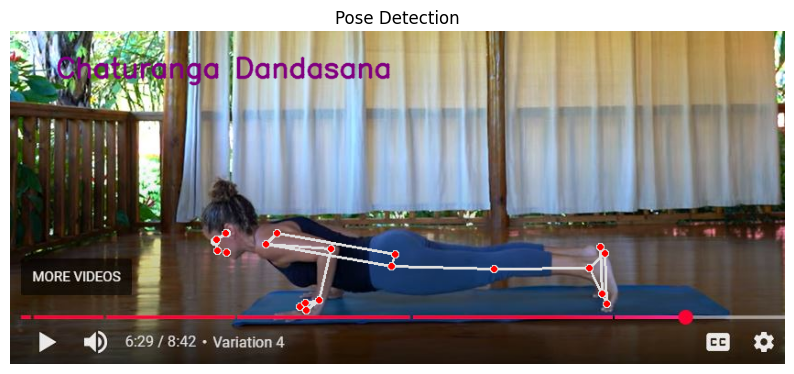

left_elbow Angle: 93.5
right_elbow Angle: 112.5
left_shoulder Angle: 12.9
right_shoulder Angle: 3.2
left_knee Angle: 174.4
right_knee Angle: 170.1
left_hip Angle: 162.2
right_hip Angle: 165.2


In [2]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = "testing/test6.jpg"  # Change this to your actual image path
image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Initialize MediaPipe Pose model
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=True, min_detection_confidence=0.5)

# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ab, cb = a - b, c - b
    cosine_angle = np.dot(ab, cb) / (np.linalg.norm(ab) * np.linalg.norm(cb))
    angle = np.degrees(np.arccos(cosine_angle))
    return angle

# Detect pose landmarks
results = pose.process(image_rgb)
if results.pose_landmarks:
    landmarks = results.pose_landmarks.landmark
    key_points = {
        "left_shoulder": mp_pose.PoseLandmark.LEFT_SHOULDER,
        "right_shoulder": mp_pose.PoseLandmark.RIGHT_SHOULDER,
        "left_elbow": mp_pose.PoseLandmark.LEFT_ELBOW,
        "right_elbow": mp_pose.PoseLandmark.RIGHT_ELBOW,
        "left_wrist": mp_pose.PoseLandmark.LEFT_WRIST,
        "right_wrist": mp_pose.PoseLandmark.RIGHT_WRIST,
        "left_hip": mp_pose.PoseLandmark.LEFT_HIP,
        "right_hip": mp_pose.PoseLandmark.RIGHT_HIP,
        "left_knee": mp_pose.PoseLandmark.LEFT_KNEE,
        "right_knee": mp_pose.PoseLandmark.RIGHT_KNEE,
        "left_ankle": mp_pose.PoseLandmark.LEFT_ANKLE,
        "right_ankle": mp_pose.PoseLandmark.RIGHT_ANKLE
    }
    points = {name: [landmarks[point.value].x, landmarks[point.value].y] for name, point in key_points.items()}
    
    angles = {
        "left_elbow": calculate_angle(points["left_shoulder"], points["left_elbow"], points["left_wrist"]),
        "right_elbow": calculate_angle(points["right_shoulder"], points["right_elbow"], points["right_wrist"]),
        "left_shoulder": calculate_angle(points["left_elbow"], points["left_shoulder"], points["left_hip"]),
        "right_shoulder": calculate_angle(points["right_elbow"], points["right_shoulder"], points["right_hip"]),
        "left_knee": calculate_angle(points["left_hip"], points["left_knee"], points["left_ankle"]),
        "right_knee": calculate_angle(points["right_hip"], points["right_knee"], points["right_ankle"]),
        "left_hip": calculate_angle(points["left_shoulder"], points["left_hip"], points["left_knee"]),
        "right_hip": calculate_angle(points["right_shoulder"], points["right_hip"], points["right_knee"])
    }

    # Pose classification
    label, color = "Unknown Pose", (0, 0, 0)

    if (165 <= angles["left_elbow"] <= 185 and 165 <= angles["right_elbow"] <= 185 and
            0 <= angles["left_shoulder"] <= 10 and 0 <= angles["right_shoulder"] <= 10 and
            160 <= angles["left_knee"] <= 185 and 160 <= angles["right_knee"] <= 185):
        label, color = 'Tadasana', (0, 128, 255)

    elif (155 <= angles["left_elbow"] <= 190 and 155 <= angles["right_elbow"] <= 190 and
            155 <= angles["left_shoulder"] <= 180 and 155 <= angles["right_shoulder"] <= 180 and 
            170 <= angles["left_knee"] <= 185 and 170 <= angles["right_knee"] <= 185):
        label, color = 'Urdhva Hastasana', (75, 0, 130)

    elif (120 <= angles["left_elbow"] <= 190 and 120 <= angles["right_elbow"] <= 190 and
            70 <= angles["left_shoulder"] <= 150 and 70 <= angles["right_shoulder"] <= 150 and 
            10 <= angles["left_hip"] <= 50 and 10 <= angles["right_hip"] <= 50 and
            120 <= angles["left_knee"] <= 190 and 120 <= angles["right_knee"] <= 190):
        label, color = 'Uttanasana', (139, 69, 19)

    elif (110 <= angles["left_elbow"] <= 185 and 110 <= angles["right_elbow"] <= 185 and
            65 <= angles["left_shoulder"] <= 130 and 65 <= angles["right_shoulder"] <= 130 and 
            30 <= angles["left_hip"] <= 90 and 30 <= angles["right_hip"] <= 90 and
            130 <= angles["left_knee"] <= 180 and 130 <= angles["right_knee"] <= 180):
        label, color = 'Ardha Uttanasana', (255, 165, 0)

    elif (150 <= angles["left_elbow"] <= 190 and 150 <= angles["right_elbow"] <= 190 and
            50 <= angles["left_shoulder"] <= 105 and 50 <= angles["right_shoulder"] <= 105 and
            100 <= angles["left_hip"] <= 180 and 100 <= angles["right_hip"] <= 180 and
            150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
        label, color = 'Phalakasana', (255, 0, 0)

    elif ( angles["left_elbow"] <= 140 and angles["right_elbow"] <= 140 and
            0 <= angles["left_shoulder"] <= 50 and 0 <= angles["right_shoulder"] <= 50 and
            150 <= angles["left_hip"] <= 190 and 150 <= angles["right_hip"] <= 190 and
            150 <= angles["left_knee"] <= 190 and 150 <= angles["right_knee"] <= 190):
        label, color = 'Chaturanga Dandasana', (128, 0, 128)

    elif (160 <= angles["left_elbow"] <= 190 and 160 <= angles["right_elbow"] <= 190 and
            5 <= angles["left_shoulder"] <= 35 and 5 <= angles["right_shoulder"] <= 35 and
            110 <= angles["left_hip"] <= 170 and 110 <= angles["right_hip"] <= 170 and
            130 <= angles["left_knee"] <= 185 and 130 <= angles["right_knee"] <= 185):
        label, color = 'Urdhva Mukha Svanasana', (255, 20, 147)

    elif (150 <= angles["left_elbow"] <= 180 and 150 <= angles["right_elbow"] <= 180 and
            155 <= angles["left_shoulder"] <= 180 and 155 <= angles["right_shoulder"] <= 180 and
            30 <= angles["left_hip"] <= 70 and 30 <= angles["right_hip"] <= 70 and
            150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
        label, color = 'Adho Mukha Svanasana', (0, 255, 255)

    # Draw landmarks and label
    annotated_image = image.copy()
    mp_drawing.draw_landmarks(annotated_image, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
    cv2.putText(annotated_image, label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

    # Convert image for display
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)

    # Display the image with detected landmarks
    plt.figure(figsize=[10, 10])
    plt.imshow(annotated_image_rgb)
    plt.title("Pose Detection")
    plt.axis("off")
    plt.show()

    # Print calculated angles
    for joint, angle in angles.items():
        print(f"{joint} Angle: {angle:.1f}")
else:
    print("No pose detected in the image.")


Detect posture with camera

In [3]:
# Detect Posture without Sequence

import cv2
import mediapipe as mp
import numpy as np

# Initialize MediaPipe Pose model
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(static_image_mode=False, min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    a, b, c = np.array(a), np.array(b), np.array(c)
    ab, cb = a - b, c - b
    cosine_angle = np.dot(ab, cb) / (np.linalg.norm(ab) * np.linalg.norm(cb))
    angle = np.degrees(np.arccos(cosine_angle))
    return angle

# Initialize webcam
cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert the frame to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Detect pose landmarks
    results = pose.process(frame_rgb)
    if results.pose_landmarks:
        landmarks = results.pose_landmarks.landmark
        key_points = {
            "left_shoulder": mp_pose.PoseLandmark.LEFT_SHOULDER,
            "right_shoulder": mp_pose.PoseLandmark.RIGHT_SHOULDER,
            "left_elbow": mp_pose.PoseLandmark.LEFT_ELBOW,
            "right_elbow": mp_pose.PoseLandmark.RIGHT_ELBOW,
            "left_wrist": mp_pose.PoseLandmark.LEFT_WRIST,
            "right_wrist": mp_pose.PoseLandmark.RIGHT_WRIST,
            "left_hip": mp_pose.PoseLandmark.LEFT_HIP,
            "right_hip": mp_pose.PoseLandmark.RIGHT_HIP,
            "left_knee": mp_pose.PoseLandmark.LEFT_KNEE,
            "right_knee": mp_pose.PoseLandmark.RIGHT_KNEE,
            "left_ankle": mp_pose.PoseLandmark.LEFT_ANKLE,
            "right_ankle": mp_pose.PoseLandmark.RIGHT_ANKLE
        }
        points = {name: [landmarks[point.value].x, landmarks[point.value].y] for name, point in key_points.items()}
        
        angles = {
            "left_elbow": calculate_angle(points["left_shoulder"], points["left_elbow"], points["left_wrist"]),
            "right_elbow": calculate_angle(points["right_shoulder"], points["right_elbow"], points["right_wrist"]),
            "left_shoulder": calculate_angle(points["left_elbow"], points["left_shoulder"], points["left_hip"]),
            "right_shoulder": calculate_angle(points["right_elbow"], points["right_shoulder"], points["right_hip"]),
            "left_knee": calculate_angle(points["left_hip"], points["left_knee"], points["left_ankle"]),
            "right_knee": calculate_angle(points["right_hip"], points["right_knee"], points["right_ankle"]),
            "left_hip": calculate_angle(points["left_shoulder"], points["left_hip"], points["left_knee"]),
            "right_hip": calculate_angle(points["right_shoulder"], points["right_hip"], points["right_knee"])
        }

        # Pose classification
        label, color = "Unknown Pose", (0, 0, 0)

        if (165 <= angles["left_elbow"] <= 185 and 165 <= angles["right_elbow"] <= 185 and
             0 <= angles["left_shoulder"] <= 10 and 0 <= angles["right_shoulder"] <= 10 and
             160 <= angles["left_knee"] <= 185 and 160 <= angles["right_knee"] <= 185):
            label, color = 'Tadasana', (0, 128, 255)

        elif (155 <= angles["left_elbow"] <= 190 and 155 <= angles["right_elbow"] <= 190 and
              155 <= angles["left_shoulder"] <= 180 and 155 <= angles["right_shoulder"] <= 180 and 
              170 <= angles["left_knee"] <= 185 and 170 <= angles["right_knee"] <= 185):
            label, color = 'Urdhva Hastasana', (75, 0, 130)

        elif (120 <= angles["left_elbow"] <= 190 and 120 <= angles["right_elbow"] <= 190 and
              70 <= angles["left_shoulder"] <= 150 and 70 <= angles["right_shoulder"] <= 150 and 
              10 <= angles["left_hip"] <= 50 and 10 <= angles["right_hip"] <= 50 and
              120 <= angles["left_knee"] <= 190 and 120 <= angles["right_knee"] <= 190):
            label, color = 'Uttanasana', (139, 69, 19)

        elif (110 <= angles["left_elbow"] <= 185 and 110 <= angles["right_elbow"] <= 185 and
              65 <= angles["left_shoulder"] <= 130 and 65 <= angles["right_shoulder"] <= 130 and 
              30 <= angles["left_hip"] <= 90 and 30 <= angles["right_hip"] <= 90 and
              130 <= angles["left_knee"] <= 180 and 130 <= angles["right_knee"] <= 180):
            label, color = 'Ardha Uttanasana', (255, 165, 0)

        elif (150 <= angles["left_elbow"] <= 190 and 150 <= angles["right_elbow"] <= 190 and
             50 <= angles["left_shoulder"] <= 105 and 50 <= angles["right_shoulder"] <= 105 and
             100 <= angles["left_hip"] <= 180 and 100 <= angles["right_hip"] <= 180 and
             150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
            label, color = 'Phalakasana', (255, 0, 0)

        elif ( angles["left_elbow"] <= 140 and angles["right_elbow"] <= 140 and
             0 <= angles["left_shoulder"] <= 50 and 0 <= angles["right_shoulder"] <= 50 and
             150 <= angles["left_hip"] <= 190 and 150 <= angles["right_hip"] <= 190 and
             150 <= angles["left_knee"] <= 190 and 150 <= angles["right_knee"] <= 190):
            label, color = 'Chaturanga Dandasana', (128, 0, 128)

        elif (160 <= angles["left_elbow"] <= 190 and 160 <= angles["right_elbow"] <= 190 and
             5 <= angles["left_shoulder"] <= 35 and 5 <= angles["right_shoulder"] <= 35 and
             110 <= angles["left_hip"] <= 170 and 110 <= angles["right_hip"] <= 170 and
             130 <= angles["left_knee"] <= 185 and 130 <= angles["right_knee"] <= 185):
            label, color = 'Urdhva Mukha Svanasana', (255, 20, 147)

        elif (150 <= angles["left_elbow"] <= 180 and 150 <= angles["right_elbow"] <= 180 and
             155 <= angles["left_shoulder"] <= 180 and 155 <= angles["right_shoulder"] <= 180 and
             30 <= angles["left_hip"] <= 70 and 30 <= angles["right_hip"] <= 70 and
             150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
            label, color = 'Adho Mukha Svanasana', (0, 255, 255)

        # Draw landmarks and label
        mp_drawing.draw_landmarks(frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS)
        cv2.putText(frame, label, (50, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, color, 2, cv2.LINE_AA)

    # Display the frame
    cv2.imshow('Pose Detection', frame)

    # Break the loop if 'q' is pressed
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release the webcam and close all OpenCV windows
cap.release()
cv2.destroyAllWindows()

Detect Poseture with sun_salutation_sequence using camera

In [4]:
# Detect Poseture with sun_salutation_sequence using camera
import cv2
import mediapipe as mp
import numpy as np

mp_pose = mp.solutions.pose

# Function to calculate the angle between three points
def calculate_angle(a, b, c):
    """
    Calculates the angle (in degrees) between three points in a 2D or 3D space.
    
    Parameters:
    a (tuple or list or array): Coordinates of the first point (e.g., (x1, y1) or (x1, y1, z1))
    b (tuple or list or array): Coordinates of the second (central) point (e.g., (x2, y2) or (x2, y2, z2))
    c (tuple or list or array): Coordinates of the third point (e.g., (x3, y3) or (x3, y3, z3))

    Returns:
    float: The angle in degrees between the three points at position `b`
    """

    # Convert input points to NumPy arrays for easier mathematical operations
    a = np.array(a)  # First point (e.g., shoulder)
    b = np.array(b)  # Central point (e.g., elbow)
    c = np.array(c)  # Third point (e.g., wrist)

    # Compute the vectors: vector ba (from b to a) and vector bc (from b to c)
    ba = a - b  # Vector from b to a
    bc = c - b  # Vector from b to c

    # Calculate the cosine of the angle using the dot product formula:
    # cos(O) = (ba * bc) / (|ba| * |bc|)
    cosine_angle = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc))

    # Convert the cosine value to an angle in radians using arccos (inverse cosine)
    angle = np.arccos(cosine_angle)

    # Convert the angle from radians to degrees
    return np.degrees(angle)




# Sun Salutation sequence
sun_salutation_sequence = [
    "Tadasana", "Urdhva Hastasana", "Uttanasana", "Ardha Uttanasana",
    "Phalakasana", "Chaturanga Dandasana", "Urdhva Mukha Svanasana", "Adho Mukha Svanasana",
    "Ardha Uttanasana", "Uttanasana", "Urdhva Hastasana", "Tadasana"
]
current_pose_index = 0 # Record the current pose to be completed
completed_rounds = 0 # Record the number of completed rounds

# Open Camera
cap = cv2.VideoCapture(0)
with mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5) as pose:
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        
        # Convert color formats
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = pose.process(image)

        # Detect key points
        if results.pose_landmarks:
            landmarks = results.pose_landmarks.landmark
            key_points = {
                "left_shoulder": mp_pose.PoseLandmark.LEFT_SHOULDER,
                "right_shoulder": mp_pose.PoseLandmark.RIGHT_SHOULDER,
                "left_elbow": mp_pose.PoseLandmark.LEFT_ELBOW,
                "right_elbow": mp_pose.PoseLandmark.RIGHT_ELBOW,
                "left_wrist": mp_pose.PoseLandmark.LEFT_WRIST,
                "right_wrist": mp_pose.PoseLandmark.RIGHT_WRIST,
                "left_hip": mp_pose.PoseLandmark.LEFT_HIP,
                "right_hip": mp_pose.PoseLandmark.RIGHT_HIP,
                "left_knee": mp_pose.PoseLandmark.LEFT_KNEE,
                "right_knee": mp_pose.PoseLandmark.RIGHT_KNEE,
                "left_ankle": mp_pose.PoseLandmark.LEFT_ANKLE,
                "right_ankle": mp_pose.PoseLandmark.RIGHT_ANKLE
            }
            points = {name: [landmarks[point.value].x, landmarks[point.value].y] for name, point in key_points.items()}

            angles = {
                "left_elbow": calculate_angle(points["left_shoulder"], points["left_elbow"], points["left_wrist"]),
                "right_elbow": calculate_angle(points["right_shoulder"], points["right_elbow"], points["right_wrist"]),
                "left_shoulder": calculate_angle(points["left_elbow"], points["left_shoulder"], points["left_hip"]),
                "right_shoulder": calculate_angle(points["right_elbow"], points["right_shoulder"], points["right_hip"]),
                "left_knee": calculate_angle(points["left_hip"], points["left_knee"], points["left_ankle"]),
                "right_knee": calculate_angle(points["right_hip"], points["right_knee"], points["right_ankle"]),
                "left_hip": calculate_angle(points["left_shoulder"], points["left_hip"], points["left_knee"]),
                "right_hip": calculate_angle(points["right_shoulder"], points["right_hip"], points["right_knee"])
            }

            # Detect current posture
            detected_pose = "Unknown"
            if (165 <= angles["left_elbow"] <= 185 and 165 <= angles["right_elbow"] <= 185 and
                0 <= angles["left_shoulder"] <= 10 and 0 <= angles["right_shoulder"] <= 10 and
                160 <= angles["left_knee"] <= 185 and 160 <= angles["right_knee"] <= 185):
                detected_pose = 'Tadasana'

            elif (155 <= angles["left_elbow"] <= 190 and 155 <= angles["right_elbow"] <= 190 and
                155 <= angles["left_shoulder"] <= 180 and 155 <= angles["right_shoulder"] <= 180 and 
                170 <= angles["left_knee"] <= 185 and 170 <= angles["right_knee"] <= 185):
                detected_pose = 'Urdhva Hastasana'

            elif (120 <= angles["left_elbow"] <= 190 and 120 <= angles["right_elbow"] <= 190 and
                70 <= angles["left_shoulder"] <= 150 and 70 <= angles["right_shoulder"] <= 150 and 
                10 <= angles["left_hip"] <= 50 and 10 <= angles["right_hip"] <= 50 and
                120 <= angles["left_knee"] <= 190 and 120 <= angles["right_knee"] <= 190):
                detected_pose = 'Uttanasana'

            elif (110 <= angles["left_elbow"] <= 185 and 110 <= angles["right_elbow"] <= 185 and
                65 <= angles["left_shoulder"] <= 130 and 65 <= angles["right_shoulder"] <= 130 and 
                30 <= angles["left_hip"] <= 90 and 30 <= angles["right_hip"] <= 90 and
                130 <= angles["left_knee"] <= 180 and 130 <= angles["right_knee"] <= 180):
                detected_pose = 'Ardha Uttanasana'



            elif (150 <= angles["left_elbow"] <= 190 and 150 <= angles["right_elbow"] <= 190 and
                50 <= angles["left_shoulder"] <= 105 and 50 <= angles["right_shoulder"] <= 105 and
                100 <= angles["left_hip"] <= 180 and 100 <= angles["right_hip"] <= 180 and
                150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
                detected_pose = 'Phalakasana'

            elif ( angles["left_elbow"] <= 140 and angles["right_elbow"] <= 140 and
                0 <= angles["left_shoulder"] <= 50 and 0 <= angles["right_shoulder"] <= 50 and
                150 <= angles["left_hip"] <= 190 and 150 <= angles["right_hip"] <= 190 and
                150 <= angles["left_knee"] <= 190 and 150 <= angles["right_knee"] <= 190):
                detected_pose = 'Chaturanga Dandasana'

            elif (160 <= angles["left_elbow"] <= 190 and 160 <= angles["right_elbow"] <= 190 and
                5 <= angles["left_shoulder"] <= 35 and 5 <= angles["right_shoulder"] <= 35 and
                110 <= angles["left_hip"] <= 170 and 110 <= angles["right_hip"] <= 170 and
                130 <= angles["left_knee"] <= 185 and 130 <= angles["right_knee"] <= 185):
                detected_pose = 'Urdhva Mukha Svanasana'

            elif (150 <= angles["left_elbow"] <= 190 and 150 <= angles["right_elbow"] <= 190 and
                150 <= angles["left_shoulder"] <= 180 and 150 <= angles["right_shoulder"] <= 180 and
                20 <= angles["left_hip"] <= 100 and 20 <= angles["right_hip"] <= 100 and
                150 <= angles["left_knee"] <= 185 and 150 <= angles["right_knee"] <= 185):
                detected_pose = 'Adho Mukha Svanasana'

            # Check if the current sequence matches the asana
            if detected_pose == sun_salutation_sequence[current_pose_index]:
                current_pose_index += 1  # Enter the next pose
                if current_pose_index >= len(sun_salutation_sequence):
                    completed_rounds += 1  # Complete a round
                    current_pose_index = 0  # Reset to the starting point

            # Show Feedback
            cv2.putText(frame, f"Pose: {detected_pose}", (30, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            cv2.putText(frame, f"Current Step: {current_pose_index} / 12", (30, 100), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 255), 2)
            
            next_pose = sun_salutation_sequence[current_pose_index] if current_pose_index < len(sun_salutation_sequence) else "Tadasana"
            cv2.putText(frame, f"Next Pose: {next_pose}", (30, 150), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

            if current_pose_index == 12:  # Assuming 12 steps in total
                cv2.putText(frame, "COMPLETE STEP!", (100, 250), cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)

            if results.pose_landmarks:
                # Draw the pose landmarks on the frame
                mp_drawing.draw_landmarks(
                    frame, results.pose_landmarks, mp_pose.POSE_CONNECTIONS,
                    mp_drawing.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=4),
                    mp_drawing.DrawingSpec(color=(255, 0, 0), thickness=2, circle_radius=2)
                )


        cv2.imshow("Sun Salutation Pose Detector", frame)
        if cv2.waitKey(10) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()
